/var/folders/vt/y6d48g2s7cg7csds0384wh400000gn/T/ipykernel_58884/141764962.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/var/folders/vt/y6d48g2s7cg7csds0384wh400000gn/T/ipykernel_58884/141764962.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

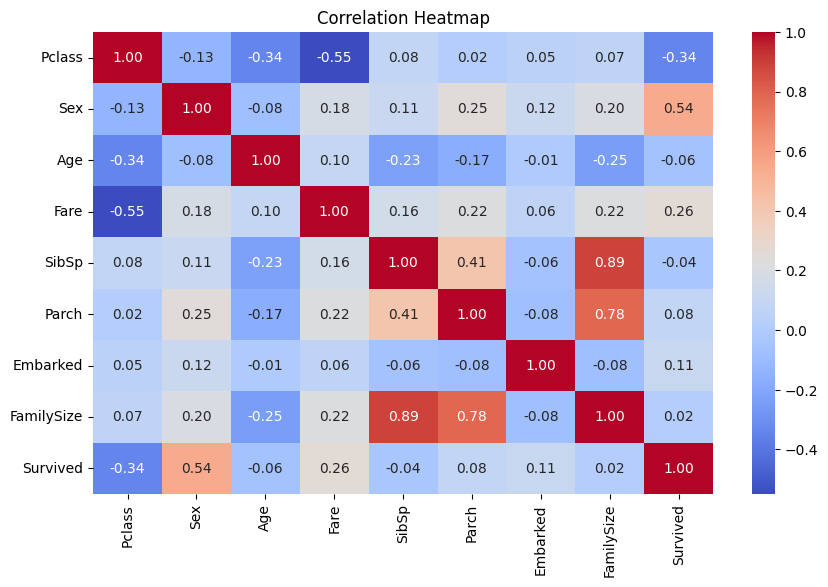


Random Forest Grid Search

Best Parameters for Random Forest:
{'bootstrap': False, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

--- Random Forest (Tuned) Evaluation ---
Accuracy : 0.8324
Precision: 0.8548
Recall   : 0.7162
F1 Score : 0.7794

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.91      0.86       105
           1       0.85      0.72      0.78        74

    accuracy                           0.83       179
   macro avg       0.84      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



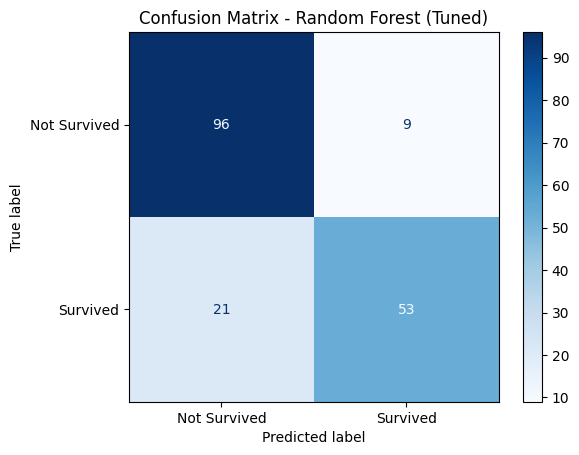


 Model Summary
                Model  Accuracy  Precision   Recall  F1 Score
Random Forest (Tuned)  0.832402   0.854839 0.716216  0.779412


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

df = pd.read_csv("/Users/siddhu/Desktop/Programs/Machine Learning/Ex8/titanic.csv")

df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

features = ["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch", "Embarked", "FamilySize"]
target = "Survived"

plt.figure(figsize=(10, 6))
sns.heatmap(df[features + [target]].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def evaluate_model(y_test, y_pred, model_name="Random Forest"):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n--- {model_name} Evaluation ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Survived", "Survived"]).plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    }

rf_params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

print("\nRandom Forest Grid Search")
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring='accuracy'
)

rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

print("\nBest Parameters for Random Forest:")
print(rf_grid.best_params_)

# Model Evaluation
rf_pred = best_rf.predict(X_test)
rf_results = evaluate_model(y_test, rf_pred, model_name="Random Forest (Tuned)")

results_df = pd.DataFrame([rf_results])
print("\n Model Summary")
print(results_df.to_string(index=False))
